# Simulating Stock Prices

Suppose we have a share of a stock with current price $S_0$ and we wish to simulate its price $S_T$ after $T$ years. Using the Geometric Brownian Motion to model stock prices, 

$$ S_T = S_0 \exp \left( \left( \mu - \frac{1}{2}\sigma^2 \right) T + \sigma \sqrt{T} z \right) $$

where $\mu$ denotes the mean log returns, $\sigma$ denotes the constant volatility, and $z \sim \mathcal{N}(0, 1)$.

In [1]:
import numpy as np
import numpy.random as npr
import yfinance as yf

In [2]:
'''
Simulating the terminal price of a given stock after a given time period.
tick_symb: ticker symbol of the stock (string)
T: time period (in years) 
num_sim: number of simulations
Returns a 1D ndarray containing num_sim simulated terminal prices.
'''

def sim_stock(tick_symb, T, num_sim):
    history = yf.Ticker(tick_symb).history(period="2y")["Close"].to_numpy()
    log_returns = np.log(history[1:] / history[:-1])

    mu = np.mean(log_returns) * 252
    sigma = np.std(log_returns) * np.sqrt(252)

    return history[-1] * np.exp((mu - 0.5 * sigma * sigma) * T + sigma * np.sqrt(T) * npr.randn(num_sim))

For example, consider the Apple stock one year from now, with $50,000$ simulations:

In [3]:
res = sim_stock("AAPL", 1, 10000)

In [4]:
import pylab as plt

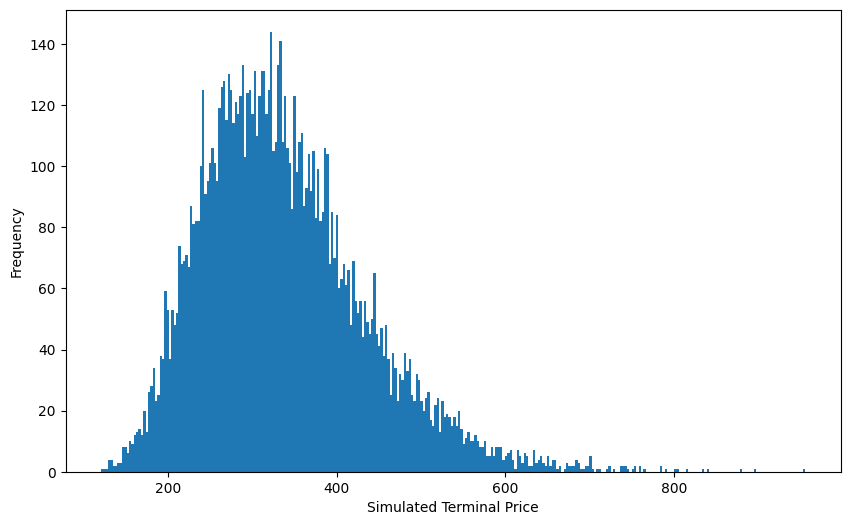

In [5]:
plt.figure(figsize=(10, 6))
plt.hist(res, bins=300)
plt.xlabel("Simulated Terminal Price")
plt.ylabel("Frequency")
plt.show()

We may also wish to simulate the entire path followed by the price of a stock. We can divide the time interval of $T$ into smaller time intervals of $\Delta t$:

$$ S_t = S_{t - \Delta t} \exp \left( \left( \mu - \frac{1}{2} \sigma^2 \right)\Delta t + \sigma \sqrt{\Delta t} z_t \right). $$


In [6]:
'''
Simulating the path of the stock price.
tick_symb: ticker symbol of the stock (string)
T: time period (in years) 
num_sim: number of simulations
N: number of time intervals in which T is divided

Returns a (N + 1)x(num_sim) ndarray, where each column contains a simulated path
'''

def sim_path_stock(tick_symb, T, num_sim, N):
    dt = T / N
    
    history = yf.Ticker(tick_symb).history(period="2y")["Close"].to_numpy()
    log_returns = np.log(history[1:] / history[:-1])

    mu = np.mean(log_returns) * 252
    sigma = np.std(log_returns) * np.sqrt(252)

    paths = np.zeros((N + 1, num_sim))
    paths[0] = history[-1]

    for t in range(1, N + 1):
        paths[t] = paths[t - 1] * np.exp((mu - 0.5 * sigma * sigma) * dt + sigma * np.sqrt(dt) * npr.randn(num_sim))

    return paths

For example, simulating the Apple stock price over a period of one year with $50$ time intervals and $10,000$ simulations:

In [7]:
paths = sim_path_stock("AAPL", 1, 10000, 50)

We use $10$ simulated paths from `paths` in the following line graph:

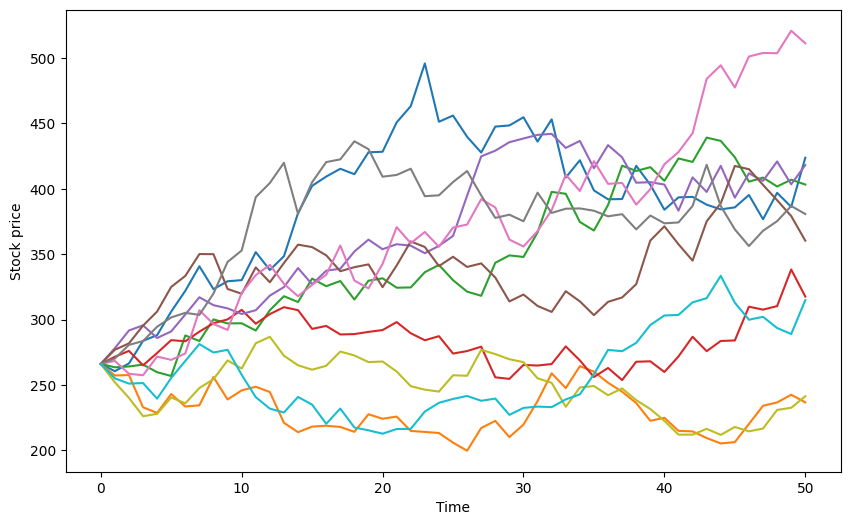

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(paths[:, :10])
plt.xlabel('Time')
plt.ylabel('Stock price')
plt.show()

The terminal prices are contained in the last row of `paths` and therefore we can plot a histogram of the terminal prices as follows:

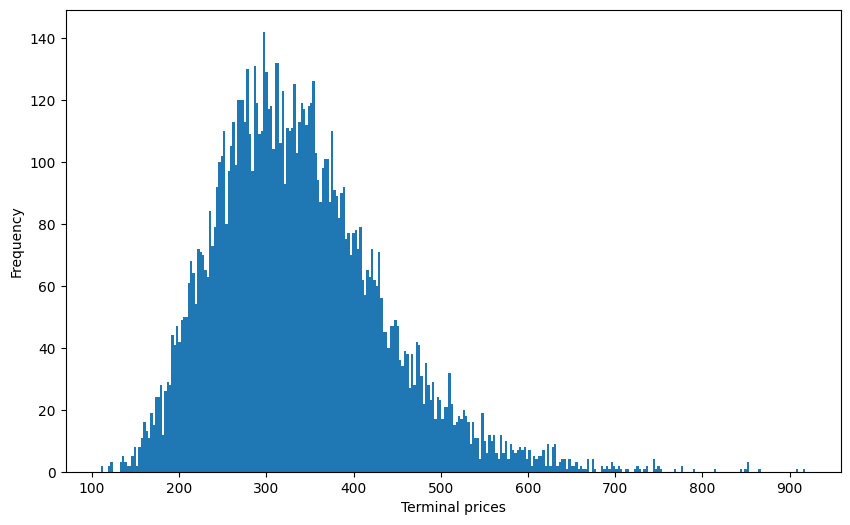

In [9]:
plt.figure(figsize=(10, 6))
plt.hist(paths[-1], bins=300)
plt.xlabel("Terminal prices")
plt.ylabel("Frequency")
plt.show()